In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('C:\\Users\\hp\\Documents\\ai-engineering-projects\\week1\\data\\application_train_cleaned.csv')

In [4]:
x=df.drop('TARGET',axis=1)
y=df['TARGET']
print(f"Features shape:{x.shape}")
print(f"Target shape:{y.shape}")
print(f"Default Rate:{y.mean()*100:.1f}%")

Features shape:(307261, 25)
Target shape:(307261,)
Default Rate:8.1%


In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f"training set:{x_train.shape[0]} samples")
print(f"test set:{x_test.shape[0]} samples")


training set:245808 samples
test set:61453 samples


In [9]:
print(x_train.dtypes)

print(x_train.head())

AGE_YEARS                                            float64
AMT_INCOME_TOTAL                                     float64
AMT_CREDIT                                           float64
AMT_ANNUITY                                          float64
CODE_GENDER                                            int64
FLAG_OWN_CAR                                           int64
FLAG_OWN_REALTY                                        int64
CNT_CHILDREN                                           int64
OCCUPATION_TYPE                                       object
NAME_EDUCATION_TYPE_Higher education                    bool
NAME_EDUCATION_TYPE_Incomplete higher                   bool
NAME_EDUCATION_TYPE_Lower secondary                     bool
NAME_EDUCATION_TYPE_Secondary / secondary special       bool
NAME_FAMILY_STATUS_Married                              bool
NAME_FAMILY_STATUS_Separated                            bool
NAME_FAMILY_STATUS_Single / not married                 bool
NAME_FAMILY_STATUS_Unkno

In [26]:
x_train = pd.get_dummies(x_train, columns=['OCCUPATION_TYPE'], dummy_na=True)
x_test = pd.get_dummies(x_test, columns=['OCCUPATION_TYPE'], dummy_na=True)

# Make sure both have the same columns
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

KeyError: "None of [Index(['OCCUPATION_TYPE'], dtype='object')] are in the [columns]"

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [28]:
##train decisoin tree 
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(max_depth=5,random_state=42)
dt_model.fit(x_train_scaled,y_train)
y_pred_dt=dt_model.predict(x_test_scaled)
y_pred_proba_dt=dt_model.predict_proba(x_test_scaled)[:,1]
print("Deision Tree Model Trained")


Deision Tree Model Trained


In [36]:
#train random forest
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf_model.fit(x_train_scaled,y_train)
# Predicted classes (0 or 1)
y_pred_rf = rf_model.predict(x_test_scaled)

# Predicted probabilities (used only for AUC)
y_pred_proba_rf = rf_model.predict_proba(x_test_scaled)[:,1]

print("Random Forest Model Trained")


Random Forest Model Trained


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

x_train[['AMT_ANNUITY']] = imputer.fit_transform(x_train[['AMT_ANNUITY']])
x_test[['AMT_ANNUITY']] = imputer.transform(x_test[['AMT_ANNUITY']])

In [37]:
#train logistic regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(x_train_scaled, y_train)
y_pred_lr = lr_model.predict(x_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(x_test_scaled)[:, 1]

print("Logistic Regression Model Trained")



Logistic Regression Model Trained


In [39]:
print(y_pred_rf[:10])

[0 0 0 0 0 0 0 0 0 0]


In [40]:
print(y_train.value_counts())
print(pd.Series(y_pred_dt).value_counts())
print(pd.Series(y_pred_rf).value_counts())

TARGET
0    225887
1     19921
Name: count, dtype: int64
0    61452
1        1
Name: count, dtype: int64
0    61453
Name: count, dtype: int64


In [41]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [43]:
from imblearn.over_sampling import SMOTE

In [45]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled,
    y_train
)

In [46]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

TARGET
0    225887
1     19921
Name: count, dtype: int64
TARGET
0    225887
1    225887
Name: count, dtype: int64


In [47]:
#decison tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(x_train_smote, y_train_smote)

y_pred_dt = dt_model.predict(x_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(x_test_scaled)[:, 1]

In [48]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(x_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(x_test_scaled)[:, 1]

In [50]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(x_train_smote, y_train_smote)

y_pred_lr = lr_model.predict(x_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(x_test_scaled)[:, 1]

In [51]:
#EVALUATE ALL MODELS:
def evaluate_model(y_true,y_pred,y_pred_proba,model_name):
    accuracy=accuracy_score(y_true,y_pred)
    precision=precision_score(y_true,y_pred)
    recall=recall_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred)
    auc=roc_auc_score(y_true,y_pred_proba)
    
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall:    {recall:.3f}")
    print(f"  F1 Score:  {f1:.3f}")
    print(f"  AUC Score: {auc:.3f}")
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC': auc
    }

print("="*60)
print("MODEL EVALUATION")
print("="*60)

results = []
results.append(evaluate_model(y_test, y_pred_dt, y_pred_proba_dt, "Decision Tree"))
results.append(evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest"))
results.append(evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, "Logistic Regression"))

# Create comparison table
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("COMPARISON")
print("="*60)
print(results_df.to_string(index=False))
    

MODEL EVALUATION

Decision Tree:
  Accuracy:  0.602
  Precision: 0.110
  Recall:    0.562
  F1 Score:  0.183
  AUC Score: 0.611

Random Forest:
  Accuracy:  0.868
  Precision: 0.124
  Recall:    0.108
  F1 Score:  0.116
  AUC Score: 0.598

Logistic Regression:
  Accuracy:  0.603
  Precision: 0.114
  Recall:    0.589
  F1 Score:  0.191
  AUC Score: 0.636

COMPARISON
              Model  Accuracy  Precision   Recall       F1      AUC
      Decision Tree  0.601923   0.109622 0.561848 0.183451 0.611021
      Random Forest  0.868306   0.124355 0.108362 0.115809 0.598297
Logistic Regression  0.602721   0.113941 0.589041 0.190946 0.635990


In [53]:
#best model analysis
best_model_name = results_df.loc[results_df['AUC'].idxmax(), 'Model']
print(f"\n Best Model: {best_model_name}")

# Get best model object
if best_model_name == "Decision Tree":
    best_model = dt_model
elif best_model_name == "Random Forest":
    best_model = rf_model
else:
    best_model = lr_model

# Feature importance (top 10 features)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-10:][::-1]
    
    plt.figure(figsize=(10, 6))
    plt.title('Top 10 Most Important Features')
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), X.columns[indices])
    plt.xlabel('Importance')
    plt.show()


 Best Model: Logistic Regression


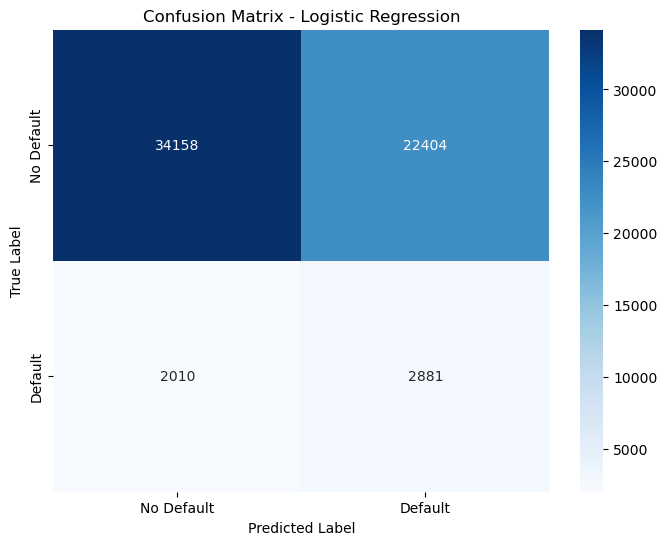

True Negatives (correct no-default):  34158
False Positives (wrong alert):        22404
False Negatives (missed defaults):    2010
True Positives (correct default):     2881


In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# For best model
y_pred_best = best_model.predict(x_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"True Negatives (correct no-default):  {cm[0,0]}")
print(f"False Positives (wrong alert):        {cm[0,1]}")
print(f"False Negatives (missed defaults):    {cm[1,0]}")
print(f"True Positives (correct default):     {cm[1,1]}")

In [56]:
print("="*60)
print("DAY 4 SUMMARY")
print("="*60)
print(f"✅ Trained 3 models")
print(f"✅ Best model: {best_model_name}")
print(f"✅ Best AUC score: {results_df['AUC'].max():.3f}")
print(f"✅ Can explain feature importance")
print(f"✅ Model ready for improvement")
print("="*60)


DAY 4 SUMMARY
✅ Trained 3 models
✅ Best model: Logistic Regression
✅ Best AUC score: 0.636
✅ Can explain feature importance
✅ Model ready for improvement
